<a href="https://colab.research.google.com/github/ItsMadtoEvil/Movie-Ratings-Analysis/blob/main/Movie_Ratings_Analysis_Using_NumPy%2C_Pandas%2C_and_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# =====================================================
# Movie Ratings Analysis Using NumPy, Pandas & Matplotlib
# =====================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# ------------------------------------------
# Load Dataset
# ------------------------------------------
url = "https://raw.githubusercontent.com/ItsMadtoEvil/Movie-Ratings-Analysis/main/movie_dataset.csv"
df = pd.read_csv(url)

In [29]:
# -----------------------------------------------------
# Display Dataset Information
# -----------------------------------------------------
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
     Title      Genre           Director  Year  Rating     Budget     Revenue
0  Movie_1   Thriller  Christopher Nolan  1987     4.5  144042878   181074389
1  Movie_2     Horror       Greta Gerwig  2019     4.2  191069324   199452586
2  Movie_3  Adventure        Guy Ritchie  1991     8.5  158923831  1011349256
3  Movie_4    Romance      Taika Waititi  2006     5.2   97414082   595721369
4  Movie_5   Thriller        Guy Ritchie  1987     6.1   59458981   170762496

Dataset Shape:
(1000, 7)

Column Names:
Index(['Title', 'Genre', 'Director', 'Year', 'Rating', 'Budget', 'Revenue'], dtype='object')

Data Types:
Title        object
Genre        object
Director     object
Year          int64
Rating      float64
Budget        int64
Revenue       int64
dtype: object

Missing Values:
Title       0
Genre       0
Director    0
Year        0
Rating      0
Budget      0
Revenue     0
dtype: int64


In [30]:
# -----------------------------------------------------
# Data Cleaning
# -----------------------------------------------------
df = df.drop_duplicates()

numeric_cols = ['Rating', 'Budget', 'Revenue']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df[numeric_cols].mean(), inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Title       0
Genre       0
Director    0
Year        0
Rating      0
Budget      0
Revenue     0
dtype: int64


In [31]:
# -----------------------------------------------------
# Statistical Analysis Using NumPy
# -----------------------------------------------------

ratings = df['Rating']

print("\n========== RATING ANALYSIS ==========")
print("Mean Rating:", np.mean(ratings))
print("Median Rating:", np.median(ratings))
print("Standard Deviation:", np.std(ratings))

budget = df['Budget']

print("\n========== BUDGET ANALYSIS ==========")
print("Mean Budget:", np.mean(budget))
print("Median Budget:", np.median(budget))
print("Standard Deviation:", np.std(budget))

revenue = df['Revenue']

print("\n========== REVENUE ANALYSIS ==========")
print("Mean Revenue:", np.mean(revenue))
print("Median Revenue:", np.median(revenue))
print("Standard Deviation:", np.std(revenue))


========== RATING ANALYSIS ==========
Mean Rating: 6.785100000000001
Median Rating: 6.9
Standard Deviation: 1.6014893037419882

========== BUDGET ANALYSIS ==========
Mean Budget: 155349664.068
Median Budget: 156231145.0
Standard Deviation: 86200096.65895599

========== REVENUE ANALYSIS ==========
Mean Revenue: 929521267.439
Median Revenue: 753437937.5
Standard Deviation: 759441096.6729255


In [32]:
# -----------------------------------------------------
# Grouped Analysis
# -----------------------------------------------------

genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

director_rating = (
    df.groupby('Director')['Rating']
    .mean()
    .sort_values(ascending=False)
)

year_rating = (
    df.groupby('Year')['Rating']
    .mean()
    .sort_index()
)

print("\nAverage Rating by Genre")
print(genre_rating)

print("\nAverage Rating by Director")
print(director_rating)

print("\nAverage Rating by Year")
print(year_rating)


Average Rating by Genre
Genre
Fantasy      7.018692
Comedy       7.014458
Animation    6.971429
Drama        6.836364
Adventure    6.823000
Action       6.784746
Sci-Fi       6.767708
Thriller     6.750000
Horror       6.475532
Romance      6.445794
Name: Rating, dtype: float64

Average Rating by Director
Director
Steven Spielberg     7.168421
Denis Villeneuve     7.058025
Quentin Tarantino    6.886585
Ridley Scott         6.871250
David Fincher        6.828916
Greta Gerwig         6.809302
James Cameron        6.767089
Guy Ritchie          6.684091
Martin Scorsese      6.661972
Christopher Nolan    6.628090
Patty Jenkins        6.520732
Taika Waititi        6.490476
Name: Rating, dtype: float64

Average Rating by Year
Year
1980    6.694118
1981    6.056000
1982    6.833333
1983    6.480000
1984    6.442857
1985    6.979167
1986    6.970000
1987    7.046154
1988    6.305000
1989    6.995652
1990    7.415000
1991    7.364706
1992    6.726087
1993    6.320000
1994    6.948000
1995    6.

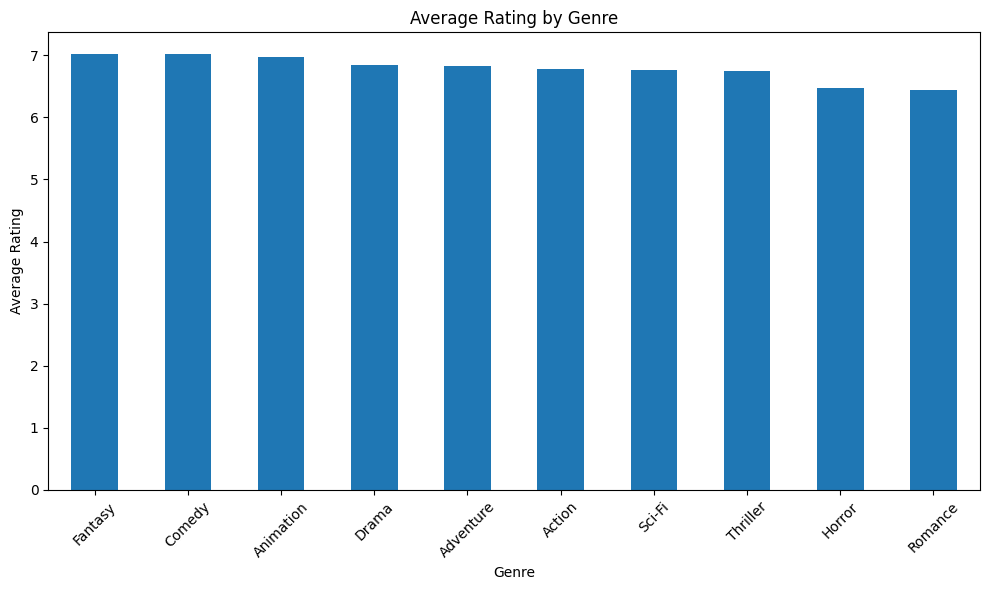

In [33]:
# -----------------------------------------------------
# Visualization 1
# Average Rating by Genre
# -----------------------------------------------------

plt.figure(figsize=(10,6))
genre_rating.plot(kind='bar')

plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

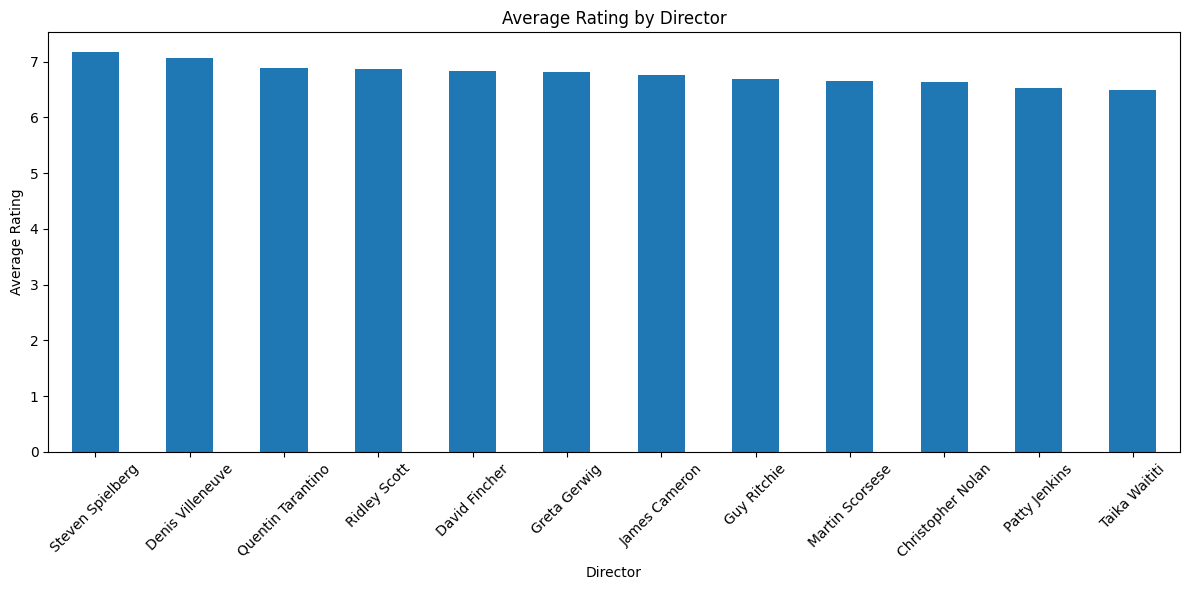

In [34]:
# -----------------------------------------------------
# Visualization 2
# Average Rating by Director
# -----------------------------------------------------

plt.figure(figsize=(12,6))
director_rating.plot(kind='bar')

plt.title("Average Rating by Director")
plt.xlabel("Director")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


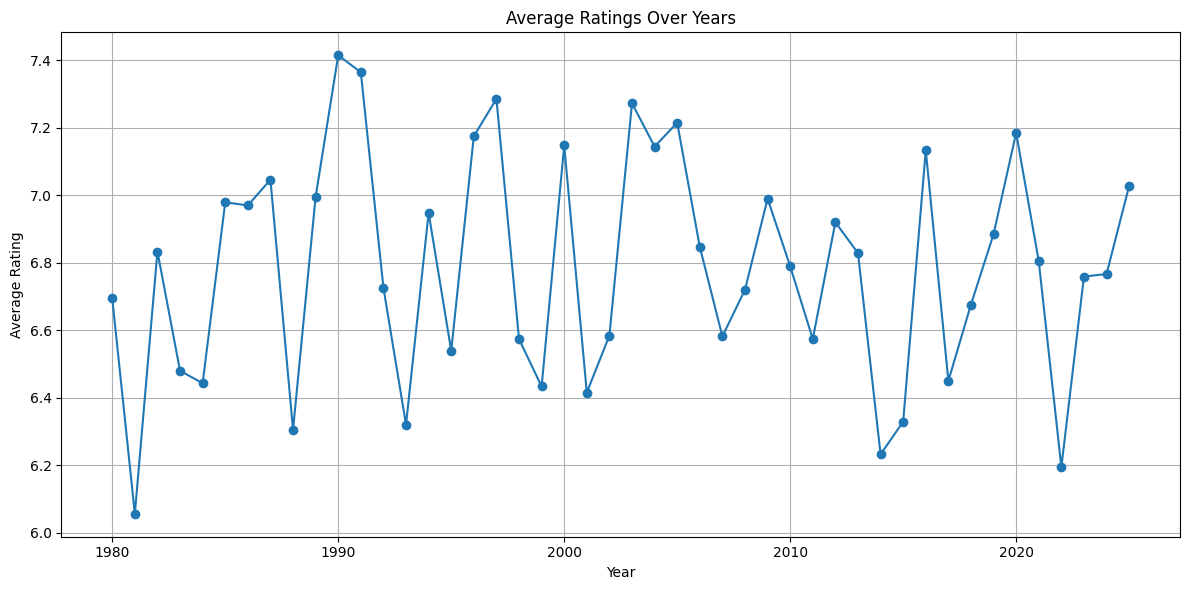

In [35]:
# -----------------------------------------------------
# Visualization 3
# Ratings Trend Over Years
# -----------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    year_rating.index,
    year_rating.values,
    marker='o'
)

plt.title("Average Ratings Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.tight_layout()
plt.show()


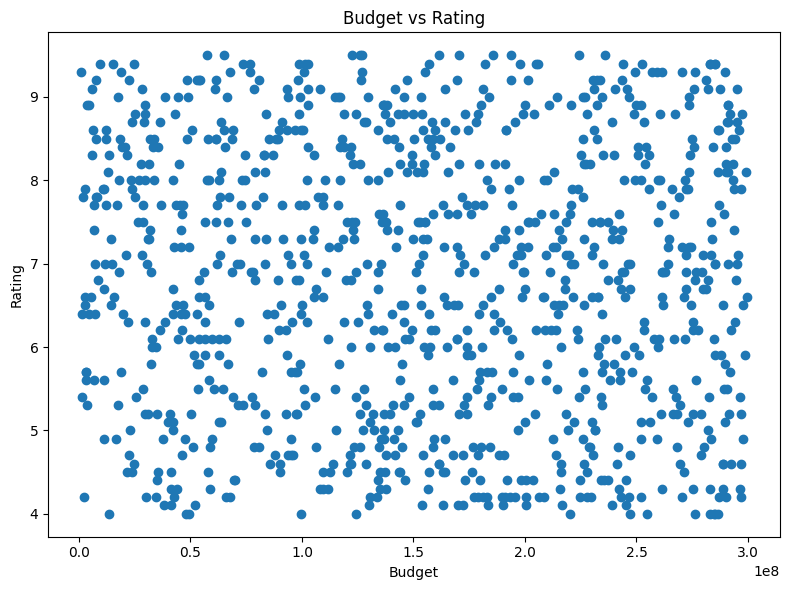

In [36]:
# -----------------------------------------------------
# Visualization 4
# Budget vs Rating
# -----------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df['Budget'],
    df['Rating']
)

plt.title("Budget vs Rating")
plt.xlabel("Budget")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()


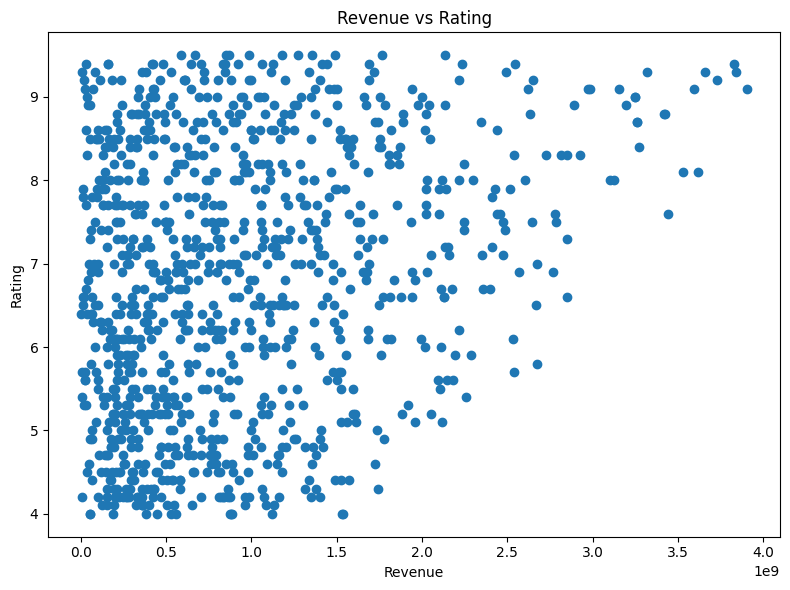

In [37]:
# -----------------------------------------------------
# Visualization 5
# Revenue vs Rating
# -----------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df['Revenue'],
    df['Rating']
)

plt.title("Revenue vs Rating")
plt.xlabel("Revenue")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()


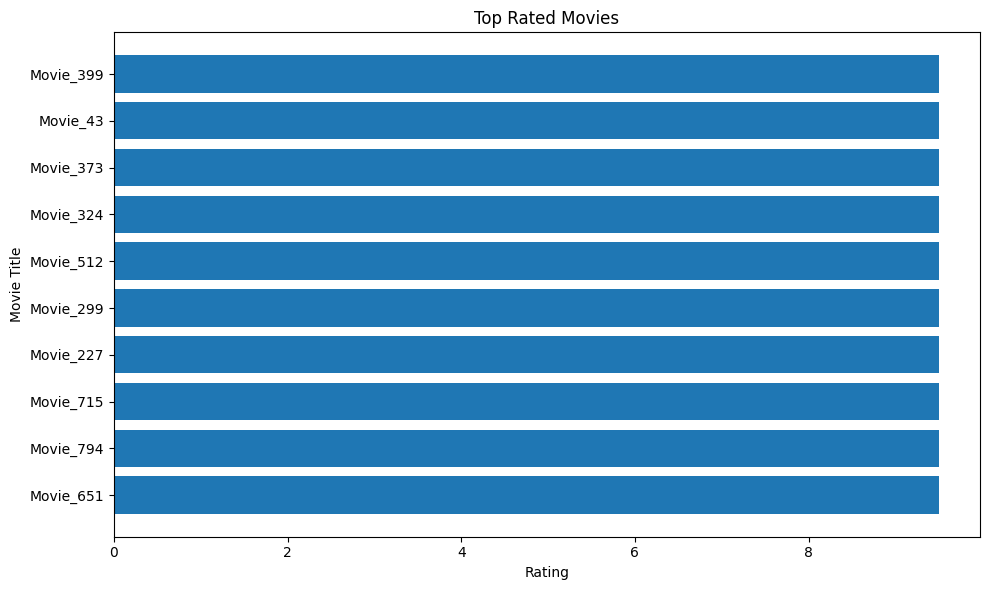

In [38]:
# -----------------------------------------------------
# Visualization 6
# Top 10 Movies by Rating
# -----------------------------------------------------

top_movies = (
    df.sort_values(
        by='Rating',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_movies['Title'],
    top_movies['Rating']
)

plt.title("Top Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()


In [39]:
# -----------------------------------------------------
# Additional Insights
# -----------------------------------------------------

highest_rated = df.loc[df['Rating'].idxmax()]

print("\nHighest Rated Movie")
print(highest_rated)

highest_revenue = df.loc[df['Revenue'].idxmax()]

print("\nHighest Revenue Movie")
print(highest_revenue)

highest_budget = df.loc[df['Budget'].idxmax()]

print("\nHighest Budget Movie")
print(highest_budget)


Highest Rated Movie
Title              Movie_43
Genre               Fantasy
Director    Martin Scorsese
Year                   2002
Rating                  9.5
Budget            122595991
Revenue          1356508187
Name: 42, dtype: object

Highest Revenue Movie
Title                 Movie_9
Genre               Adventure
Director    Quentin Tarantino
Year                     2012
Rating                    9.1
Budget              295027954
Revenue            3903541379
Name: 8, dtype: object

Highest Budget Movie
Title              Movie_349
Genre                 Comedy
Director    Denis Villeneuve
Year                    1993
Rating                   6.6
Budget             299433583
Revenue           2126281853
Name: 348, dtype: object
